# Setup

In [ ]:
%%capture
%pip install --quiet pydantic-ai sentence-transformers numpy mcp nest_asyncio openai pandas
# Patch asyncio for Jupyter (REQUIRED — run this before any agent call)
import nest_asyncio
nest_asyncio.apply()

In [ ]:
# Set your OpenRouter API key
OPENROUTER_API_KEY = ''

import os, getpass
if OPENROUTER_API_KEY:
    os.environ['OPENROUTER_API_KEY'] = OPENROUTER_API_KEY
elif 'OPENROUTER_API_KEY' not in os.environ:
    os.environ['OPENROUTER_API_KEY'] = getpass.getpass('OpenRouter API key: ')

In [ ]:
from pydantic_ai.models.openai import OpenAIChatModel
from pydantic_ai.providers.openai import OpenAIProvider

MODEL = OpenAIChatModel(
    'openai/gpt-4o-mini',
    # 'openai/gpt-5.4-mini',
    provider=OpenAIProvider(
        base_url='https://openrouter.ai/api/v1',
        api_key=os.environ['OPENROUTER_API_KEY'],
    ),
)

# Calling LLMs from Python

In [ ]:
from pydantic_ai.direct import model_request_sync
from pydantic_ai import ModelRequest

response = model_request_sync(
    model=MODEL,
    messages=[ModelRequest.user_text_prompt("Tell me a joke")],
)

print(response.parts)

In [ ]:
from pydantic_ai import Agent

plain_agent = Agent(MODEL)
result = plain_agent.run_sync('Tell me a joke')

print(result.output)

In [ ]:
result = plain_agent.run_sync('Hi my name is Fred')
print(result.output)
result = plain_agent.run_sync('What is my name?')
print(result.output)

In [ ]:
from pydantic_ai import Agent

styled_agent = Agent(MODEL, system_prompt="Always respond as a character from idiocracy.")
result = styled_agent.run_sync('Tell me a joke')

print(result.output)

# Tools

In [ ]:
result = plain_agent.run_sync('What OS does this computer have?')
print(result.output)

In [ ]:
from pydantic_ai import Tool
import platform

def get_os():
    """Returns the operating system of the current machine."""
    return platform.system()

Tool(get_os).tool_def

In [ ]:
tool_agent = Agent(MODEL, tools=[get_os])
result = tool_agent.run_sync('What OS does this computer have?')
print(result.output)

In [ ]:
def pretty_print_trace(result, messages=None):
    if messages is None:
        messages = result.all_messages()
    for i, msg in enumerate(messages):
        print(f'\n[{i}] {type(msg).__name__}')
        for part in getattr(msg, "parts", []):
            kind = type(part).__name__
            snippet = repr(part)
            print(f'    └─ {kind}: {snippet}')

pretty_print_trace(result)

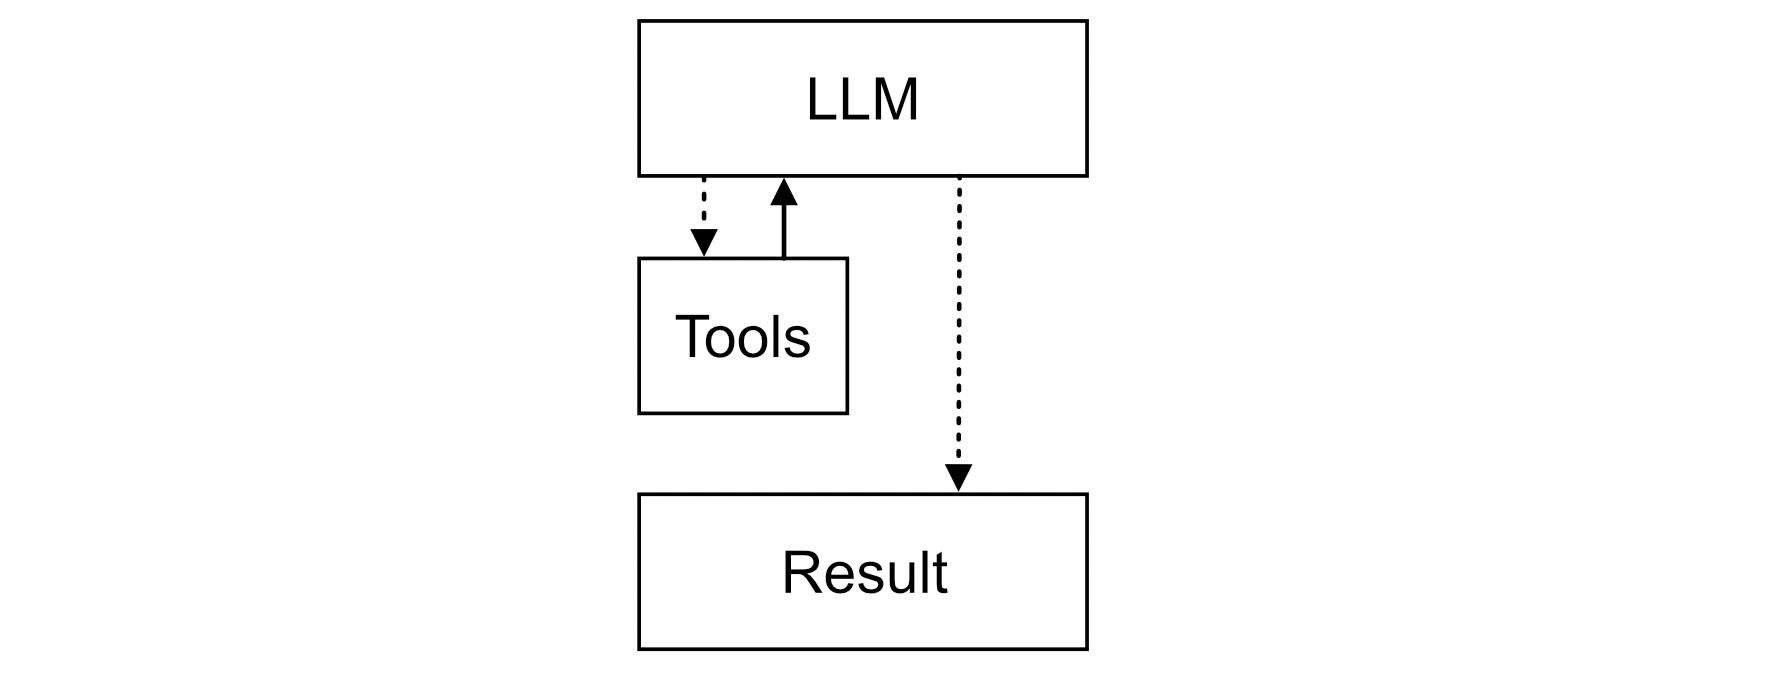

# Exercise 1 - GC content

In [ ]:
import random
dna_sequence = "".join(random.choices("ATGC", weights=[0.15,0.15,0.35,0.35], k=100))
Agent(MODEL).run_sync(f"Whats the GC content of {dna_sequence}?")

In [ ]:
# Exercise 1 - Create an agent with a tool to calculate GC content and ask him to calculate it for dna_sequence
# The GC content of the sequence is the percentage of either G or C in the sequence, for example 84.5
def get_gc_content(sequence: str): #parameters must be typed
    #TODO
    pass

get_gc_content('GCCCTATA')

In [ ]:
gc_agent = #TODO
result = #TODO
pretty_print_trace(result)

# Exercise 2 - Data inspector

In [ ]:
# Setup - run this to create a csv with random DNA sequences
import random
import pandas as pd

def make_an_experiment_csv(num_of_samples, csv_path, seed=42):
    rng = random.Random(seed)
    sequence_lengths = [rng.randint(100, 1000) for _ in range(num_of_samples)]
    pd.DataFrame({
        "sequence": [
            "".join(rng.choices("ATCG", k=sequence_lengths[i]))
            for i in range(num_of_samples)
        ],
        "sequence_len": sequence_lengths,
        "score": [100/(rng.random()*sequence_lengths[i]) for i in range(num_of_samples)]
    }).to_csv(csv_path, index=False)

make_an_experiment_csv(2000, "experiment_1.csv", 42)
make_an_experiment_csv(1000, "experiment_2.csv", 321)

In [ ]:
import pandas as pd
def get_csv_stats(csv_path: str) -> dict|str:
    """
    Args:
        csv_path: path to the csv file
    Returns:
        A dictionary with the statistics of the csv file or an error message if the file doesn't exist
    """
    try:
        return pd.read_csv(csv_path).describe().to_dict() #tool return value need to be JSON-serializable
    except FileNotFoundError: #We have to handle agent's potential errors, otherwise the run can crash
        return f"{csv_path} doesn't exist"

print(get_csv_stats('experiment_1.csv'))
print(get_csv_stats('experiment_2.csv'))

In [ ]:
# Exercise 2 - Create an agent that uses the get_csv_stats tool to answer questions about the experiment CSV files
csv_agent = #TODO

In [ ]:
pretty_print_trace(csv_agent.run_sync("What is the highest score across all experiments?"))

In [ ]:
pretty_print_trace(csv_agent.run_sync("Which experiment has more sequences?"))

In [ ]:
pretty_print_trace(csv_agent.run_sync("What is the last 4 nucleotides of the longest sequence from experiment 1?"))

# Tool fail cases

In [ ]:
def get_sequence(csv_file: str, sequence_col: str, idx: int) -> str:
    """
    Args:
        csv_file: path to csv file
        sequence_col: name of column containing sequences
        idx: index of csv row of interest 
    Returns:
        sequence at row idx
    """
    try:
        return pd.read_csv(csv_file).iloc[idx][sequence_col]
    except FileNotFoundError:
        return f"{csv_file} not found"
    except IndexError:
        return f"Index {idx} out of range"
    except KeyError:
        return f"Column {sequence_col} not found"
    
def get_gc_content(sequence: str): #parameters must be typed
    """Returns GC content of a single sequence"""
    return 100 * (sequence.count("G") + sequence.count("C")) / len(sequence)

def get_csv_length(csv_file: str):
    try:
        return len(pd.read_csv(csv_file))
    except FileNotFoundError:
        return f"{csv_file} not found"

def get_csv_cols(csv_file: str):
    try:
        return pd.read_csv(csv_file).columns.to_list()
    except FileNotFoundError:
        return f"{csv_file} not found"

def list_cwd():
    return os.listdir()

get_sequence("experiment_1.csv", "sequence", 200)

In [ ]:
from pydantic_ai import UsageLimits, capture_run_messages, UsageLimitExceeded

inefficient_agent = Agent(
    MODEL, 
    tools=[get_gc_content, get_sequence, list_cwd, get_csv_length, get_csv_cols],
)

with capture_run_messages() as messages:
    try:
        result = inefficient_agent.run_sync(
            "What is the maximum GC sequence content of all sequences from the first experiment?", 
            usage_limits=UsageLimits(tool_calls_limit=10)
        )
        pretty_print_trace(result)
    except UsageLimitExceeded as e:
        print('Agent ran out of tool calls')
        pretty_print_trace(result=None, messages=messages)
    

# The spectrum of power

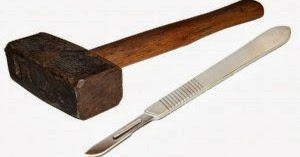

In [ ]:
# tradeoff of tools: hard-to-use, general, and powerful VS easy-to-use, specialized, and controlled
import subprocess
def bash(command: str) -> str:
    result = subprocess.run(command, shell=True, capture_output=True, text=True)
    return result.stdout if result.returncode == 0 else result.stderr

bash('ls -la')